## homework 1

I have picked the generalized normal distribution because we can relatievly easy get the kurtosis we want by just chaning one parameter and it behaves "nicely"

the pdf of the generalized normal distribution is

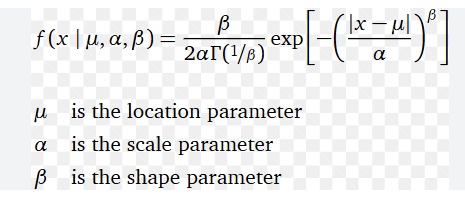

the four moments of generalized normal distribution is

mean = μ

variance = 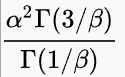

skewness = 0

excess kurtosis = 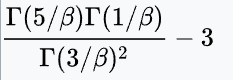

## Calculate parameters of the distribution to match required moments

In [99]:
from scipy.stats import gennorm, norm, skew, kurtosis
from scipy.optimize import bisect
from scipy.special import gamma

import numpy as np
import matplotlib.pyplot as plt

required moments:

skewness is 0 by default

In [100]:
SD = 2.4
mean = 0
excess_kurt = 16.5

find beta so that excess kurtosis = 16.5

kurtosis of generalized normal distribution is Γ(5/beta)*Γ(1/beta) / Γ(3/beta)**2

which means the EXCESS kurtosis is Γ(5/beta)*Γ(1/beta) / Γ(3/beta)**2 - 3

where Γ is the gamma function

use bisection method to find the beta that gives required excess kurtosis

In [102]:
def kurt(beta):
    return gamma(5/beta)*gamma(1/beta) / ( gamma(3/beta)**2 ) - 3 - excess_kurt #subtract excess_kurt because we will find the beta that makes this output 0

In [103]:
opt_beta = bisect(kurt, 0.1 , 10)
opt_beta

0.5487275399450823

In [104]:
gamma(5/opt_beta)*gamma(1/opt_beta) / ( gamma(3/opt_beta)**2 ) - 3

np.float64(16.500000000012538)

for the generalized normal distribution the variance is alpha**2 * Γ(3/beta) / Γ(1/beta)

standard devation is alpha * sqrt( Γ(3/beta) / Γ(1/beta) )

we need to find alpha so that SD is 2.4

alpha = SD / sqrt( Γ(3/beta) / Γ(1/beta) )

In [105]:
alpha = SD / ( gamma(3/opt_beta) / gamma(1/opt_beta) )**(1/2)

check if the parameters we found are correct

In [106]:
gennorm.stats(opt_beta,scale=alpha,loc=mean, moments='mvsk')

(np.float64(0.0),
 np.float64(5.760000000000002),
 np.float64(0.0),
 np.float64(16.500000000012534))

mean skewness and kurtosis is correct, the second number is variance so we need to calculate the standard devation

In [107]:
(gennorm.stats(opt_beta,scale=alpha,loc=mean, moments='mvsk')[1])**(1/2)

np.float64(2.4000000000000004)

Standard deviation is also correct!

In [112]:
print(f"the parameters beta={opt_beta}, scale={alpha}, loc={mean} gives the correct given moments")

the parameters beta=0.5487275399450823, scale=0.3297819073962311, loc=0 gives the correct given moments


## sampling:

In [118]:
samples = gennorm.rvs(opt_beta, scale=alpha, loc=mean, size=1000)

In [119]:
sample_mean = np.mean(samples)
sample_std = np.std(samples)
sample_skewness = skew(samples)
sample_kurtosis = kurtosis(samples)  # this gives excess kurtosis

print(f"mean={sample_mean}")
print(f"standard devation={sample_std}")
print(f"skewness={sample_skewness}")
print(f"excess kurtosis={sample_kurtosis}")

mean=0.04059732069362642
standard devation=2.534240217294774
skewness=0.9725191025884922
excess kurtosis=16.687246096746044


the sample moments are close the desired values, skewness is quite high. This happens when we only have 1000 samples

## plots

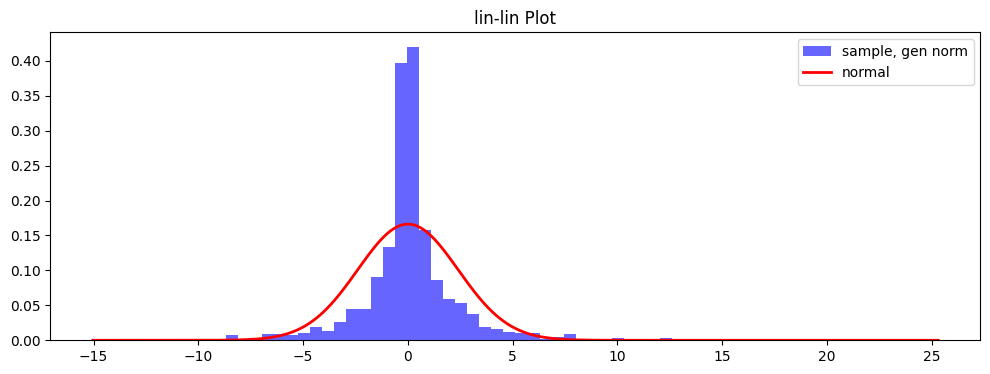

In [128]:
x = np.linspace(min(samples), max(samples), 1000)
norm_pdf = norm.pdf(x, loc=mean, scale=SD)

plt.figure(figsize=(12, 4))

#plt.subplot(1, 3, 1)
plt.hist(samples, bins=70, density=True, alpha=0.6, color='b', label='sample, gen norm')
plt.plot(x, norm_pdf, 'r-', lw=2, label='normal')
plt.title('lin-lin Plot')
plt.legend()

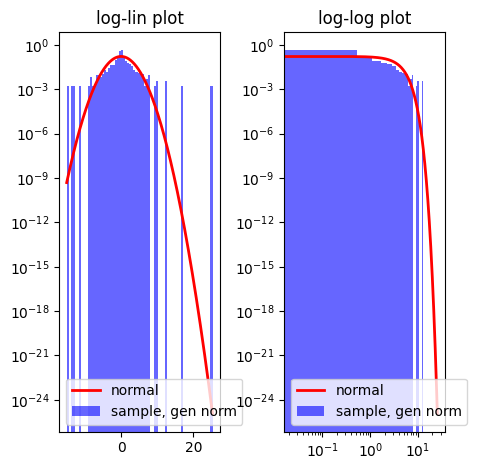

In [134]:
# log-lin
plt.subplot(1, 3, 2)
plt.semilogy(x, norm_pdf, 'r-', lw=2, label='normal')
plt.hist(samples, bins=70, density=True, alpha=0.6, color='b', label='sample, gen norm', log=True)
plt.title('log-lin plot')
plt.legend()

# log-log
plt.subplot(1, 3, 3)
plt.loglog(x, norm_pdf, 'r-', lw=2, label='normal')
plt.hist(samples, bins=70, density=True, alpha=0.6, color='b', label='sample, gen norm', log=True)
plt.title('log-log plot')
plt.legend()

plt.tight_layout()
plt.show()

in the log-lin plot we see that we have samples where a regular normal distribution probably would not, this is because of the high excess kurtosis

if skewness were also non-zero one could use a generalized skew-normal distribution